In [1]:
#first we want to import the different files, 311, ACS, and TIGER/Line files

#figure out, how to combine them, census tracts

import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point

#Load ACS data
acs_data = pd.read_csv('nhgis0005_csv/nhgis0005_ds226_20165_tract.csv', low_memory=False)

#Load TIGER/Line shapefile
shapefile = gpd.read_file('tl_2016_36_tract/tl_2016_36_tract.shp')

#Load 311 data
df_311 = pd.read_csv('311_Service_Requests.csv', low_memory=False)

In [2]:
#join total pop data from block group dataset to acs_data with socioeconomic data
#load total pop data
totalpop = pd.read_csv('nhgis0006_csv/nhgis0006_ds225_20165_tract.csv',usecols=['GEOID', 'AF2LE001'], low_memory=False)
totalpop = totalpop.drop(index=0)
totalpop = totalpop.reset_index(drop=True)

acs_data = acs_data.merge(totalpop, on='GEOID', how='left')

In [3]:
medianincome = pd.read_csv('nhgis0007_csv/nhgis0007_ds225_20165_tract.csv',usecols=['GEOID', 'AF49E001'], low_memory=False)
medianincome = medianincome.drop(index=0)
medianincome = medianincome.reset_index(drop=True)

acs_data = acs_data.merge(medianincome, on='GEOID', how='left')

In [4]:
#print(acs_data['AF49E001'])

In [5]:
#Clean ACS Data

#clean GEOID Data
#drop identifier row
acs_data = acs_data.drop(index=0)
acs_data = acs_data.reset_index(drop=True)


#Remove 14000US
acs_data.columns = acs_data.columns.str.strip()
acs_data['GEOID'] = acs_data['GEOID'].str.replace('14000US', '', regex=False)
acs_data['GEOID'] = acs_data['GEOID'].astype(str) 
acs_data['GEOID'] = acs_data['GEOID'].str.strip()

acs_data.dropna(axis=1, thresh=0.95 * len(acs_data), inplace=True)
acs_data = acs_data.reset_index(drop=True)

#print(acs_data['GEOID'])
#print(acs_data.isnull().sum().tolist())
#print(acs_data.columns.tolist())

In [6]:
#print(acs_data) 
#print(shapefile) 
nyc_acs = acs_data[acs_data['STATE'] == 'New York'] 
nyc_counties = ['Bronx County', 'New York County', 'Kings County', 'Richmond County', 'Queens County']
nyc_acs = nyc_acs[nyc_acs['COUNTY'].isin(nyc_counties)]
nyc_county_fips = ['005', '047', '061', '081', '085']
shapefile = shapefile[shapefile['COUNTYFP'].isin(nyc_county_fips)]
nyc_acs = nyc_acs.reset_index(drop=True)
shapefile = shapefile.reset_index(drop=True)
print(nyc_acs['COUNTY'].unique()) #
print(shapefile['COUNTYFP'].unique())

acs_tiger = shapefile.merge(acs_data, on='GEOID', how='left')

#generate all different types of complaint counts, then create extra columns to append to the dataset.

<StringArray>
[   'Bronx County',    'Kings County', 'New York County',   'Queens County',
 'Richmond County']
Length: 5, dtype: str
<StringArray>
['081', '047', '061', '005', '085']
Length: 5, dtype: str


In [7]:
if 'AF2LE001' in acs_tiger.columns:
    acs_tiger.rename(columns={
        'AF2LE001': 'Total_Population',
        'AGBTE001': 'White_Population',
        'AGBUE001': 'Black_Population',
        'AGB1E001': 'Hispanic_Population',
        'AGBWE001': 'Asian_Population',
        'AF49E001': 'Median_Household_Income'
    }, inplace=True)
else:
    print("Error")

#div by zero
acs_tiger['Total_Population'] = acs_tiger['Total_Population'].replace(0, np.nan)

for col in ['White_Population', 
            'Black_Population', 
            'Hispanic_Population',
            'Asian_Population',
            'AGBVE001',
            'AGBXE001',
            'AGBYE001',
            'AGBZE001',
            'Total_Population',
            'Median_Household_Income'
           ]:
    try:
        acs_tiger[col] = pd.to_numeric(acs_tiger[col], errors='coerce') 
    except:
        print(f"Error converting column {col}") 

#percentages
acs_tiger['Percent_White'] = acs_tiger['White_Population'] / acs_tiger['Total_Population']
acs_tiger['Percent_Black'] = acs_tiger['Black_Population'] / acs_tiger['Total_Population']
acs_tiger['Percent_Hispanic'] = acs_tiger['Hispanic_Population'] / acs_tiger['Total_Population']
acs_tiger['Percent_Asian'] = acs_tiger['Asian_Population'] / acs_tiger['Total_Population']
acs_tiger['Percent_Other'] = (acs_tiger['AGBVE001'] + acs_tiger['AGBXE001'] + acs_tiger['AGBYE001'] + acs_tiger['AGBZE001']) / acs_tiger['Total_Population']

In [8]:
#print(len(df_311['Latitude']))
#print(len(df_311['Longitude']))
#df_311 = df_311.dropna(subset=['Latitude', 'Longitude'])
#print(len(df_311['Latitude']))
#print(len(df_311['Longitude']))

#convert 'Created Date' to datetime using the correct format
df_311['Created Date'] = pd.to_datetime(df_311['Created Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df_311 = df_311[df_311['Created Date'].dt.year == 2016]

#convert latitude and longitude to numeric types
df_311['Latitude'] = pd.to_numeric(df_311['Latitude'], errors='coerce')
df_311['Longitude'] = pd.to_numeric(df_311['Longitude'], errors='coerce')
df_311 = df_311.dropna(subset=['Latitude', 'Longitude'])

#print(len(df_311['Latitude']))
#print(len(df_311['Longitude']))


In [9]:
#print(df_311['Complaint Type'].unique())

#define a mapping for the complaint categories
complaint_categories = {
    'Noise Complaints': [
        'Noise - Residential', 'Noise - Commercial', 'Noise', 'Noise - House of Worship',
        'Noise - Park', 'Noise - Street/Sidewalk', 'Noise - Vehicle', 'Noise - Helicopter',
        'Collection Truck Noise'
    ],
    'Housing and Building Complaints': [
        'HEAT/HOT WATER', 'PAINT/PLASTER', 'UNSANITARY CONDITION', 'WATER LEAK',
        'PLUMBING', 'Electrical', 'ELEVATOR', 'Lead', 'MOLD', 'Indoor Air Quality',
        'Indoor Sewage', 'APPLIANCE', 'DOOR/WINDOW', 'FLOORING/STAIRS', 'Building/Use',
        'Building Condition', 'Boilers', 'Non-Residential Heat', 'Vacant Lot',
        'Construction', 'General Construction/Plumbing', 'BEST/Site Safety',
        'Scaffold Safety', 'Asbestos/Garbage Nuisance', 'Asbestos', 'Building Marshals office',
        'Interior Demo', 'Facades', 'Special Projects Inspection Team (SPIT)', 'Mold', 'OUTSIDE BUILDING',
        'Elevator', 'ELECTRIC','Plumbing', 'DRIE', 'Window Guard', 'Tanning', 'VACANT APARTMENT'
        
    ],
    'Sanitation and Environmental Complaints': [
        'Dirty Conditions', 'Sanitation Condition', 'Overflowing Litter Baskets',
        'Overflowing Recycling Baskets', 'Hazardous Materials', 'Air Quality',
        'Water Quality', 'Water System', 'Sewer', 'Industrial Waste', 'Rodent',
        'Unsanitary Pigeon Condition', 'Animal Abuse', 'Animal Facility - No Permit',
        'Unsanitary Animal Pvt Property', 'Unsanitary Animal Facility', 'Dead/Dying Tree',
        'Dead Tree', 'Damaged Tree', 'Illegal Tree Damage', 'Root/Sewer/Sidewalk Condition',
        'Water Conservation', 'Standing Water', 'Poison Ivy', 'Smoking', 'Harboring Bees/Wasps',
        'Mosquitoes', 'Food Poisoning', 'Food Establishment', 'Calorie Labeling', 'Trans Fat', 
        'Missed Collection (All Materials)', 'Drinking Water', 'Sustainability Enforcement', 
        'Adopt-A-Basket', 'Tattooing', 'Beach/Pool/Sauna Complaint', 'Bottled Water',
        'Radioactive Material', 'LEAD','Trapping Pigeon'
        
    ],
    'Street and Infrastructure Complaints': [
        'Illegal Parking', 'Blocked Driveway', 'Derelict Vehicle', 'Derelict Vehicles',
        'Derelict Bicycle', 'Traffic Signal Condition', 'Street Condition',
        'Street Light Condition', 'Sidewalk Condition', 'Street Sign - Dangling',
        'Street Sign - Damaged', 'Street Sign - Missing', 'Broken Muni Meter',
        'Broken Parking Meter', 'Curb Condition', 'Overgrown Tree/Branches',
        'New Tree Request', 'Highway Condition', 'Bridge Condition', 'Bus Stop Shelter Complaint',
        'Bus Stop Shelter Placement', 'Bike Rack Condition', 'Bike/Roller/Skate Chronic',
        'Traffic', 'LinkNYC', 'Snow', 'Plant', 'Municipal Parking Facility',
        'Litter Basket / Request', 'Electronics Waste', 'Transportation Provider Complaint',
        'Construction Safety Enforcement', 'Street Sign', 'Cranes and Derricks', 'Stalled Sites',
        'Maintenance or Facility', 'Sweeping/Missed', 'Sweeping/Inadequate', 'City Vehicle Placard Complaint',
        'Posting Advertisement', 'Special Natural Area District (SNAD)', 'SRDE', 'OEM Disabled Vehicle', 
        'Request Xmas Tree Collection'
        
    ],
    'Public Safety and Quality of Life Complaints': [
        'Drug Activity', 'Non-Emergency Police Matter', 'Homeless Person Assistance',
        'Homeless Encampment', 'Panhandling', 'Disorderly Youth', 'Urinating in Public',
        'Public Payphone Complaint', 'Vending', 'For Hire Vehicle Report',
        'For Hire Vehicle Complaint', 'Taxi Complaint', 'Taxi Report', 'Unleashed Dog',
        'Squeegee', 'Illegal Animal Kept as Pet', 'Illegal Animal Sold', 'Quality of Life',
        'Illegal Fireworks', 'Violation of Park Rules', 'Animal in a Park', 'DPR Internal',
        'Recycling Enforcement', 'Public Toilet', 'Graffiti', 'Other Enforcement', 'Consumer Complaint',
        'GENERAL', 'SAFETY', 'School Maintenance', 'Drinking','Emergency Response Team (ERT)', 
        'Investigations and Discipline (IAD)', 'Senior Center Complaint', 'Miscellaneous Categories', 
        'FATF', 'Day Care', 'ATF', 'Found Property', 'Taxpayer Advocate Inquiry', 'Advocate-Commercial Exemptions',
        'Lifeguard', 'Literature Request','Legal Services Provider Complaint', 'Advocate-Business Tax', 
        'Forensic Engineering', 'X-Ray Machine/Equipment', 'ZTESTINT', 'AGENCY', 'Advocate-UBT', 'Advocate - Other'
    ]
}

def map_complaint_category(complaint_type):
    for category, types in complaint_categories.items():
        if complaint_type in types:
            return category
    return 'OtherComplaints'  #uncategorized, if any 

df_311['Complaint Category'] = df_311['Complaint Type'].apply(map_complaint_category)

In [10]:
#create geometry column
geometry = [Point(xy) for xy in zip(df_311['Longitude'], df_311['Latitude'])]
gdf_311 = gpd.GeoDataFrame(df_311, geometry=geometry)

#print(acs_tiger.crs)
#print(gdf_311.crs)

#set crs to acs_tiger crs
gdf_311.set_crs('EPSG:4269', inplace=True)
acs_tiger = acs_tiger.to_crs('EPSG:4269')


gdf_merged = gpd.sjoin(gdf_311, acs_tiger, how='left', predicate='within')
#gdf_merged = gpd.sjoin(gdf_311, acs_tiger, how='left')
#gdf_merged = gdf_merged[gdf_merged.geometry.within(acs_tiger.unary_union)]

In [11]:
#make sure 'GEOID' is not null
gdf_merged = gdf_merged.dropna(subset=['GEOID'])

#group by GEOID and Complaint Category
complaints_by_tract = gdf_merged.groupby(['GEOID', 'Complaint Category']).size().reset_index(name='Complaint_Count')

#pivot data to have complaint categories as columns
complaints_pivot = complaints_by_tract.pivot(index='GEOID', columns='Complaint Category', values='Complaint_Count').fillna(0)
complaints_pivot = complaints_pivot.reset_index()

In [12]:
#merge back with acs_tiger
acs_tiger = acs_tiger.merge(complaints_pivot, on='GEOID', how='left')

#fill NaN for 0 if any
complaint_categories_list = list(complaint_categories.keys())
acs_tiger[complaint_categories_list] = acs_tiger[complaint_categories_list].fillna(0)

In [13]:
#complaint rates per 1,000 people
#replace 0 in Total_Population with NaN to avoid division by zero
acs_tiger['Total_Population'] = acs_tiger['Total_Population'].replace(0, np.nan)
acs_tiger['Median_Household_Income'] = acs_tiger['Median_Household_Income'].replace(0, np.nan)

#cut out totalpop < 500
population_threshold = 500
acs_tiger = acs_tiger[acs_tiger['Total_Population'] >= population_threshold]

for category in complaint_categories_list:
    acs_tiger[f'{category}_Per_1000_People'] = (acs_tiger[category] / acs_tiger['Total_Population']) * 1000
    #print(f'{category}_Per_1000_People')

#replace inf and NaN with 0 for visualization purposes
acs_tiger.replace([np.inf, -np.inf], np.nan, inplace=True)
acs_tiger.fillna(0, inplace=True)

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,...,Housing and Building Complaints,Noise Complaints,Public Safety and Quality of Life Complaints,Sanitation and Environmental Complaints,Street and Infrastructure Complaints,Noise Complaints_Per_1000_People,Housing and Building Complaints_Per_1000_People,Sanitation and Environmental Complaints_Per_1000_People,Street and Infrastructure Complaints_Per_1000_People,Public Safety and Quality of Life Complaints_Per_1000_People
0,36,081,003400,36081003400,34,Census Tract 34,G5020,S,213987,0,...,71.0,84.0,38.0,169.0,412.0,32.646716,27.594248,65.682083,160.124368,14.768752
1,36,081,003900,36081003900,39,Census Tract 39,G5020,S,146970,0,...,150.0,33.0,51.0,71.0,256.0,19.903498,90.470446,42.822678,154.402895,30.759952
2,36,081,003600,36081003600,36,Census Tract 36,G5020,S,180006,0,...,96.0,149.0,37.0,180.0,406.0,38.903394,25.065274,46.997389,106.005222,9.660574
4,36,081,003800,36081003800,38,Census Tract 38,G5020,S,176214,0,...,206.0,127.0,29.0,103.0,282.0,50.396825,81.746032,40.873016,111.904762,11.507937
5,36,081,004001,36081004001,40.01,Census Tract 40.01,G5020,S,174292,0,...,95.0,72.0,38.0,117.0,370.0,31.760035,41.905602,51.610057,163.211292,16.762241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2162,36,061,022600,36061022600,226,Census Tract 226,G5020,S,152979,0,...,866.0,708.0,122.0,232.0,307.0,155.161078,189.787421,50.843743,67.280298,26.736796
2163,36,061,022800,36061022800,228,Census Tract 228,G5020,S,180634,0,...,1481.0,398.0,310.0,246.0,167.0,64.349232,239.450283,39.773646,27.000808,50.121261
2164,36,061,022900,36061022900,229,Census Tract 229,G5020,S,211053,131446,...,1308.0,1211.0,266.0,212.0,148.0,143.534432,155.031409,25.127415,17.541780,31.527794
2165,36,061,023000,36061023000,230,Census Tract 230,G5020,S,173684,0,...,1695.0,925.0,208.0,264.0,150.0,98.383323,180.280791,28.079132,15.954052,22.122953


In [14]:
#data for all complaint categories
for category in complaint_categories_list:
    column_name = f"{category}_Per_1000_People"
    if column_name in acs_tiger.columns:
        #calculate min and max
        min_value = acs_tiger[column_name].min()
        max_value = acs_tiger[column_name].max()
        print(f"Range of {category} per 1,000 People: {min_value} to {max_value}")
        
        #print summary statistics
        print(acs_tiger[column_name].describe())
        print("\n")  
    else:
        print(f"{column_name} not found in the dataset.")

Range of Noise Complaints per 1,000 People: 0.0 to 1016.20029455081
count    2099.000000
mean       47.617319
std        54.429292
min         0.000000
25%        18.275664
50%        32.752501
75%        58.710018
max      1016.200295
Name: Noise Complaints_Per_1000_People, dtype: float64


Range of Housing and Building Complaints per 1,000 People: 0.0 to 742.3277359583093
count    2099.000000
mean       74.575824
std        68.477276
min         0.000000
25%        27.523545
50%        51.177904
75%       100.975148
max       742.327736
Name: Housing and Building Complaints_Per_1000_People, dtype: float64


Range of Sanitation and Environmental Complaints per 1,000 People: 0.7996801279488205 to 260.13513513513516
count    2099.000000
mean       44.179278
std        25.420325
min         0.799680
25%        26.830867
50%        39.607843
75%        56.434513
max       260.135135
Name: Sanitation and Environmental Complaints_Per_1000_People, dtype: float64


Range of Street and Infrast

In [15]:

acs_tiger['Noise Complaints_Per_1000_People'] = pd.to_numeric(acs_tiger['Noise Complaints_Per_1000_People'], errors='coerce')
acs_tiger['Housing and Building Complaints_Per_1000_People'] = pd.to_numeric(acs_tiger['Housing and Building Complaints_Per_1000_People'], errors='coerce')
acs_tiger['Sanitation and Environmental Complaints_Per_1000_People'] = pd.to_numeric(acs_tiger['Sanitation and Environmental Complaints_Per_1000_People'], errors='coerce')
acs_tiger['Street and Infrastructure Complaints_Per_1000_People'] = pd.to_numeric(acs_tiger['Street and Infrastructure Complaints_Per_1000_People'], errors='coerce')
acs_tiger['Public Safety and Quality of Life Complaints_Per_1000_People'] = pd.to_numeric(acs_tiger['Public Safety and Quality of Life Complaints_Per_1000_People'], errors='coerce')


acs_tiger['Noise Complaints_Per_1000_PeopleCLIP'] = acs_tiger['Noise Complaints_Per_1000_People'].clip(upper=400)
acs_tiger['Housing and Building Complaints_Per_1000_PeopleCLIP'] = acs_tiger['Housing and Building Complaints_Per_1000_People'].clip(upper=400)
acs_tiger['Sanitation and Environmental Complaints_Per_1000_PeopleCLIP'] = acs_tiger['Sanitation and Environmental Complaints_Per_1000_People'].clip(upper=400)
acs_tiger['Street and Infrastructure Complaints_Per_1000_PeopleCLIP'] = acs_tiger['Street and Infrastructure Complaints_Per_1000_People'].clip(upper=400)
acs_tiger['Public Safety and Quality of Life Complaints_Per_1000_PeopleCLIP'] = acs_tiger['Public Safety and Quality of Life Complaints_Per_1000_People'].clip(upper=400)


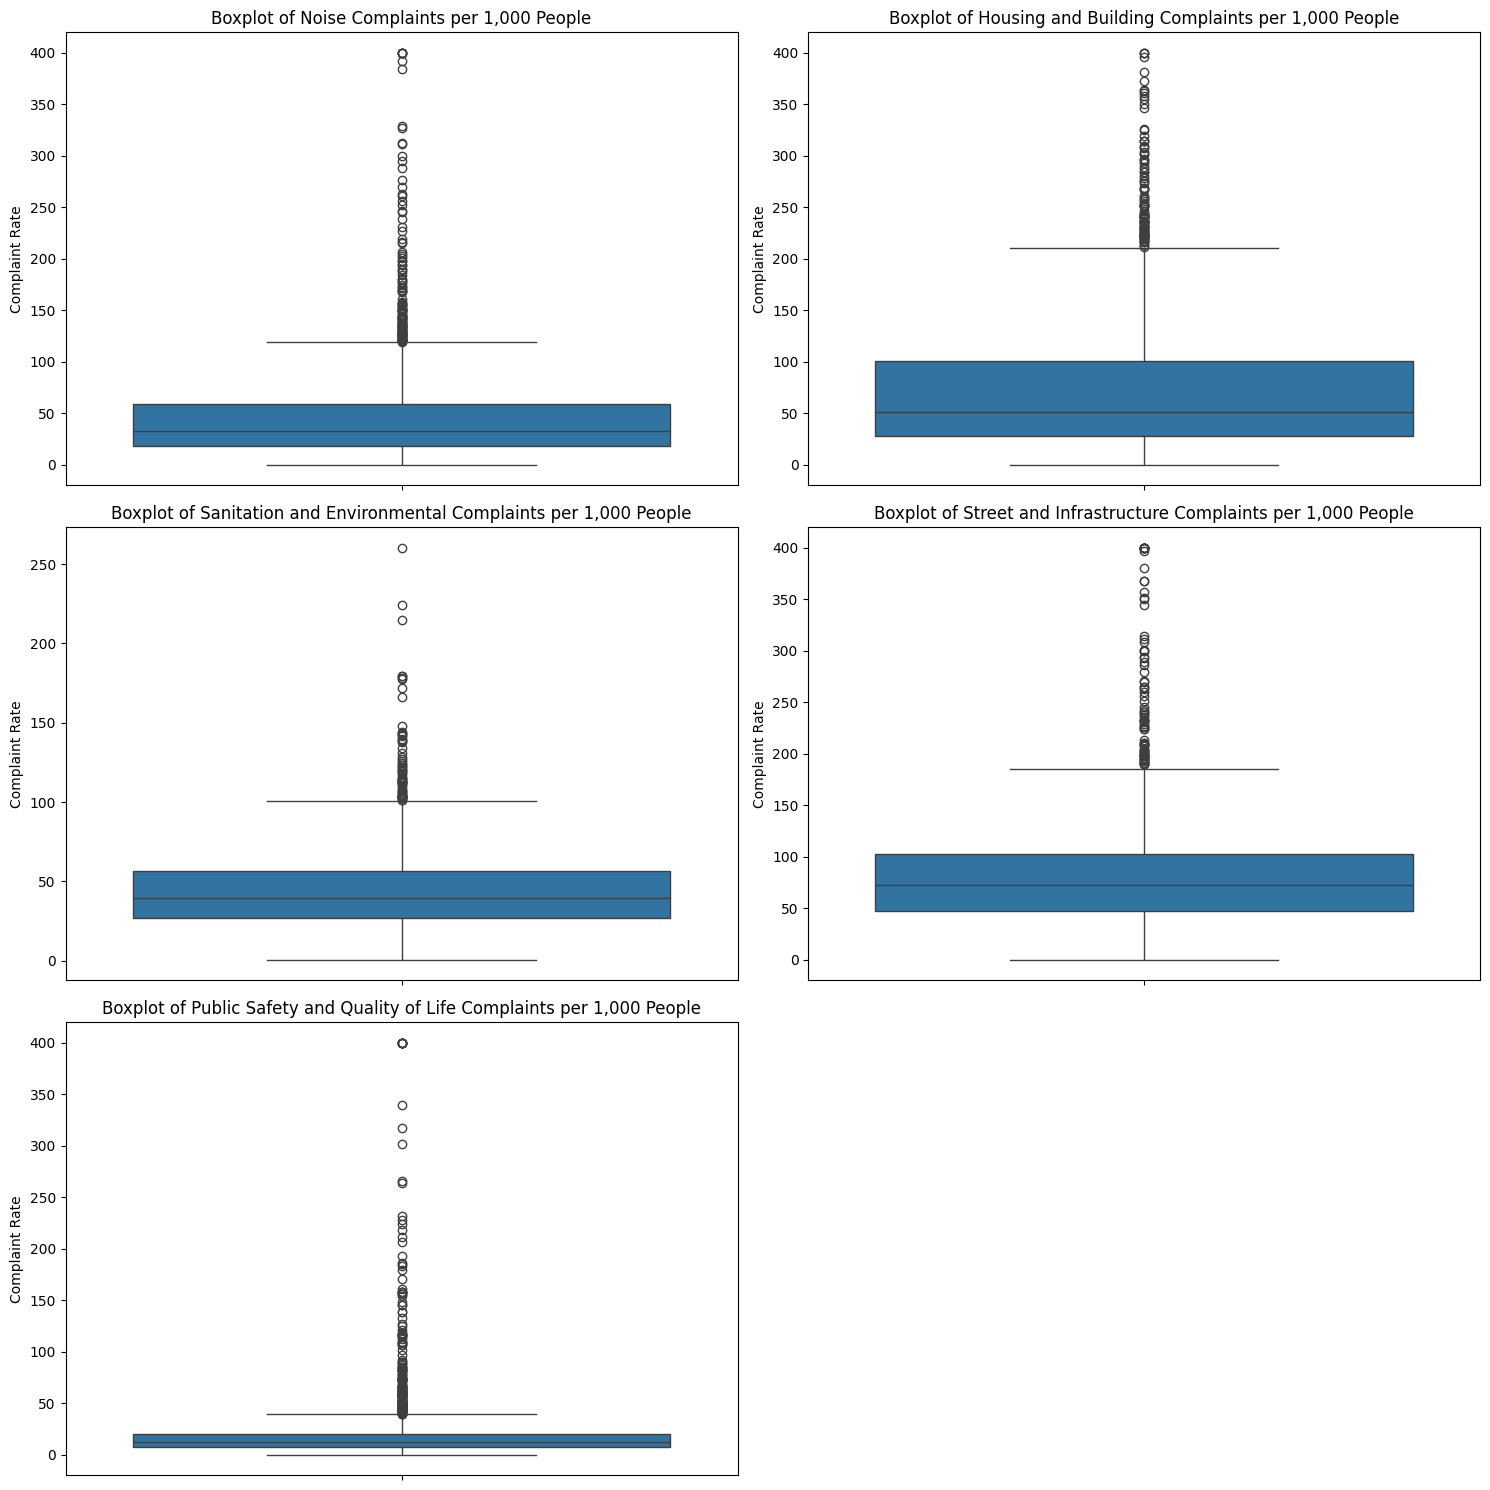

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

n_categories = len(complaint_categories_list)
n_cols = 2
n_rows = (n_categories + 1) // n_cols  


fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() 


for i, category in enumerate(complaint_categories_list):
    column_name = f'{category}_Per_1000_PeopleCLIP'
    sns.boxplot(y=acs_tiger[column_name], ax=axes[i])
    axes[i].set_title(f'Boxplot of {category} per 1,000 People')
    axes[i].set_ylabel('Complaint Rate')


for j in range(i + 1, len(axes)):
    axes[j].axis('off')


plt.tight_layout()
plt.show()

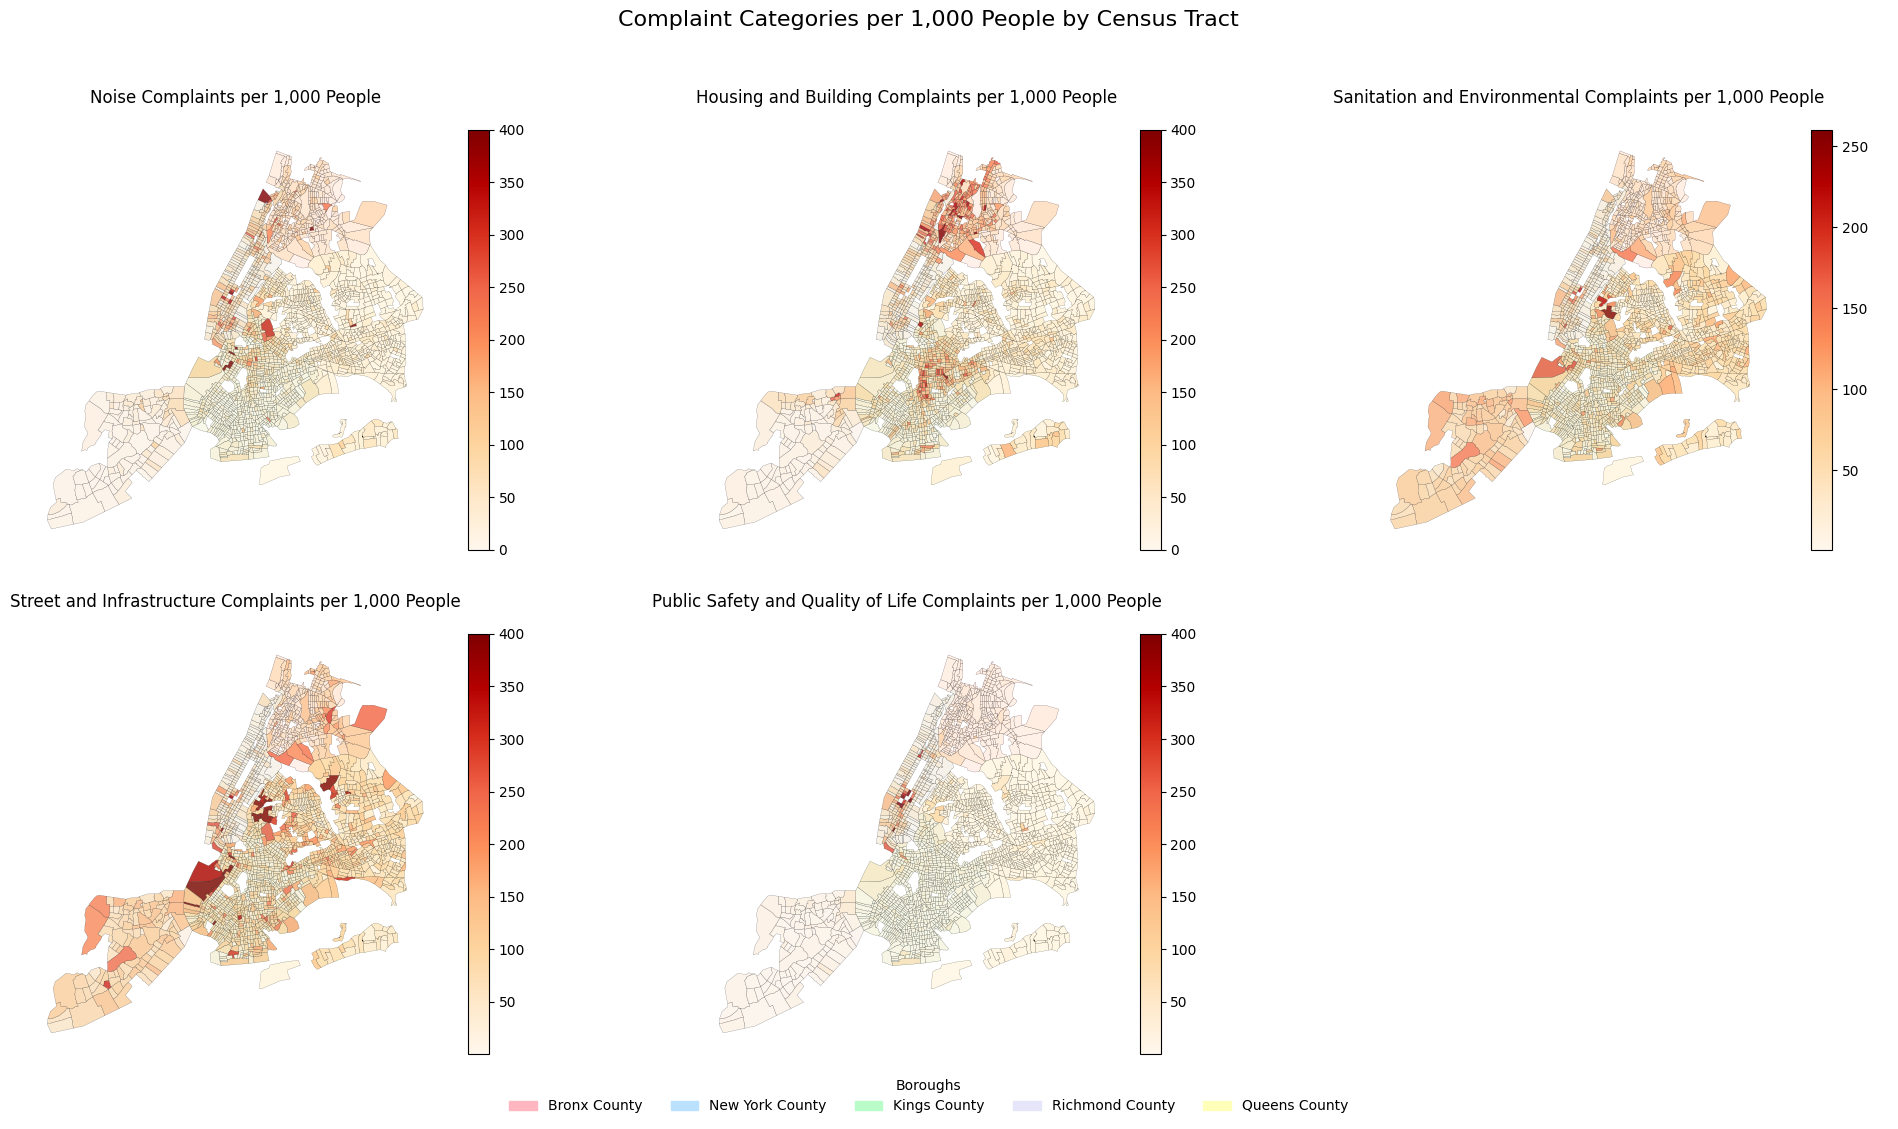

In [19]:
borough_colors = {
    'Bronx County': '#FFB6C1',  #pastel pink
    'New York County': '#BAE1FF',  #pastel blue
    'Kings County': '#B9FBC9',  #pastel green
    'Richmond County': '#E6E6FA',  #pastel lavender
    'Queens County': '#FFFFBA',  #pastel yellow
}


if 'COUNTY' in acs_tiger.columns:
    #set borough colors
    acs_tiger['Borough_Color'] = acs_tiger['COUNTY'].map(borough_colors)
else:
    print("Borough data not found. Skipping borough coloring.")


n_categories = len(complaint_categories_list)
n_cols = 3  
n_rows = -(-n_categories // n_cols) 

#subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 12))
plt.subplots_adjust(hspace=0.2, wspace=0.3)  #space between rows and columns


axes = axes.flatten()

#all complaint categories plotted
for idx, category in enumerate(complaint_categories_list):
    column_name = f"{category}_Per_1000_PeopleCLIP"
    

    if column_name in acs_tiger.columns:
        #borough boundaries with transparency
        for borough, color in borough_colors.items():
            borough_subset = acs_tiger[acs_tiger['COUNTY'] == borough]
            borough_subset.plot(
                color=color,
                ax=axes[idx],
                edgecolor='none',
                alpha=0.5  #borough shading
            )
        
        #complaint data overlay
        acs_tiger.plot(
            column=column_name,
            ax=axes[idx],
            cmap='OrRd',
            legend=True,
            missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
            edgecolor='black',  #boundaries for census tracts
            linewidth=0.12,      #tract boundary lines
            alpha=0.8           #overlay transparency
        )
        
        #title and axis
        axes[idx].set_title(f"{category} per 1,000 People", fontsize=12, y=1.05)
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, f"No Data for {category}", ha='center', va='center')
        axes[idx].set_title(f"{category}", fontsize=12)
        axes[idx].axis('off')


for i in range(len(axes)):
    if i >= n_categories:
        axes[i].axis('off')

#legend
legend_patches = [
    mpatches.Patch(color=color, label=borough)
    for borough, color in borough_colors.items()
]
fig.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=5, 
    frameon=False,
    title='Boroughs',
    bbox_to_anchor=(0.5, 0.05) 
)


plt.tight_layout 
fig.suptitle('Complaint Categories per 1,000 People by Census Tract', fontsize=16)


plt.show()

In [20]:
import matplotlib.pyplot as plt

variables = [
    'Median_Household_Income', 'Percent_White', 'Percent_Black',
    'Percent_Hispanic', 'Percent_Asian', 'Percent_Other',
    'Noise Complaints_Per_1000_People',
    'Housing and Building Complaints_Per_1000_People',
    'Sanitation and Environmental Complaints_Per_1000_People',
    'Street and Infrastructure Complaints_Per_1000_People',
    'Public Safety and Quality of Life Complaints_Per_1000_People'
]


analysis_data = acs_tiger[variables].dropna()

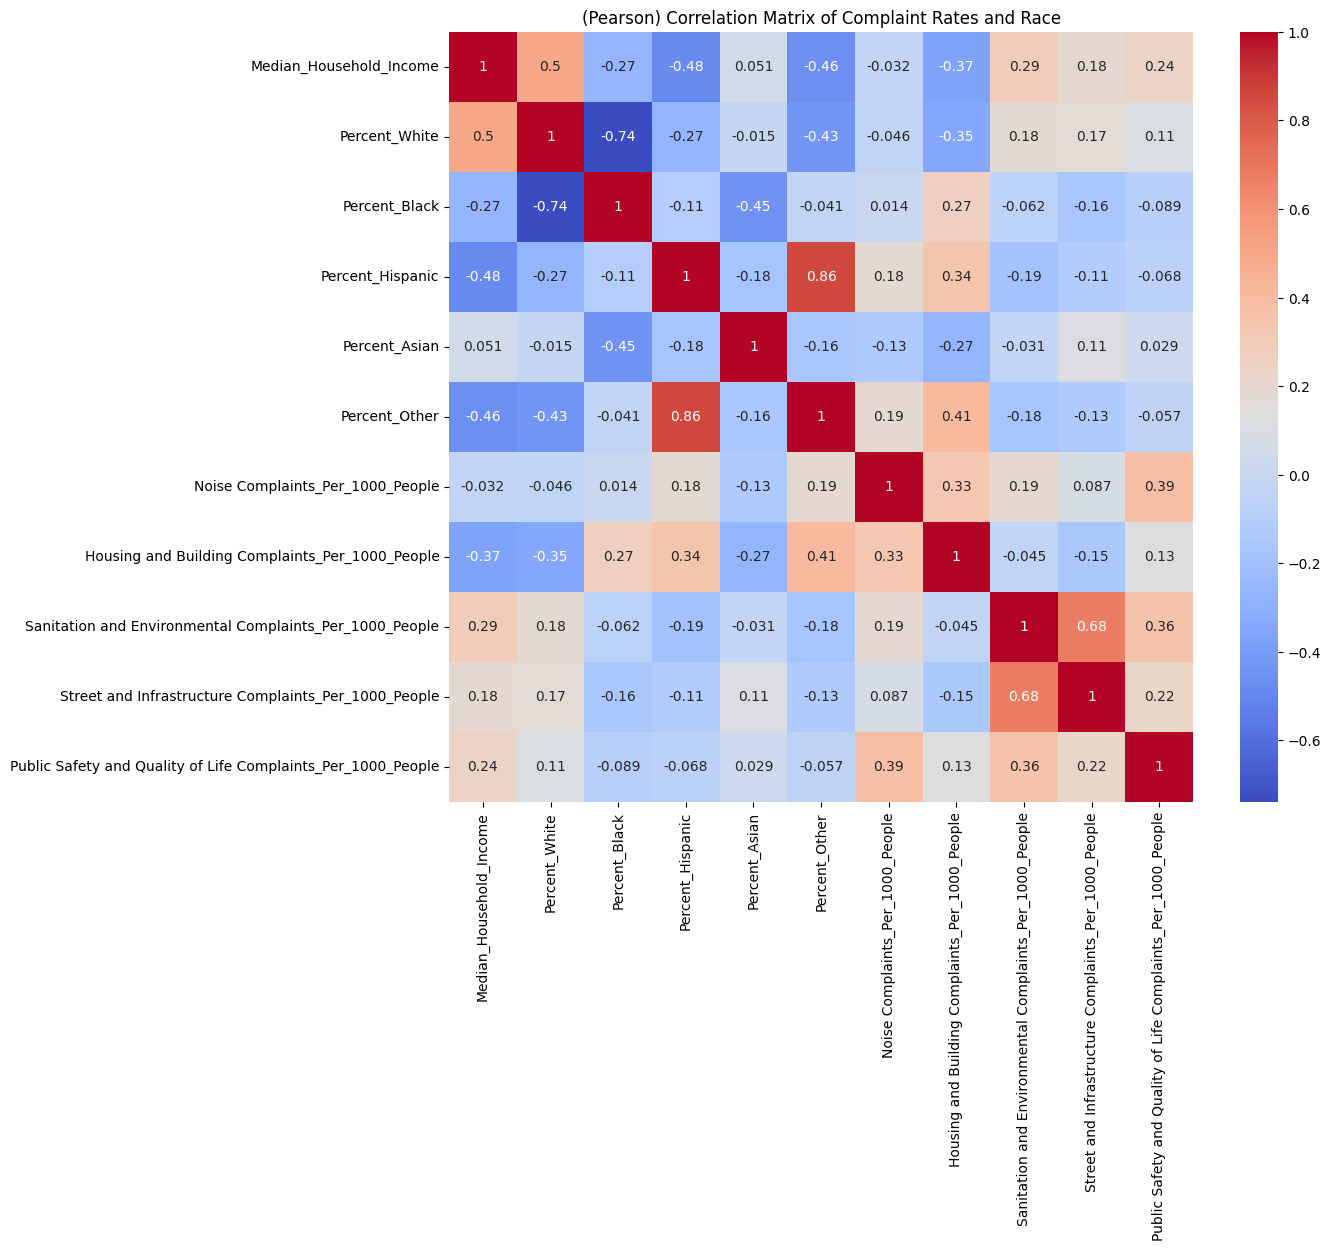

In [21]:
#Pearson
#correlation matrix
corr_matrix = analysis_data.corr(method = 'pearson')

#heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('(Pearson) Correlation Matrix of Complaint Rates and Race')
plt.show()

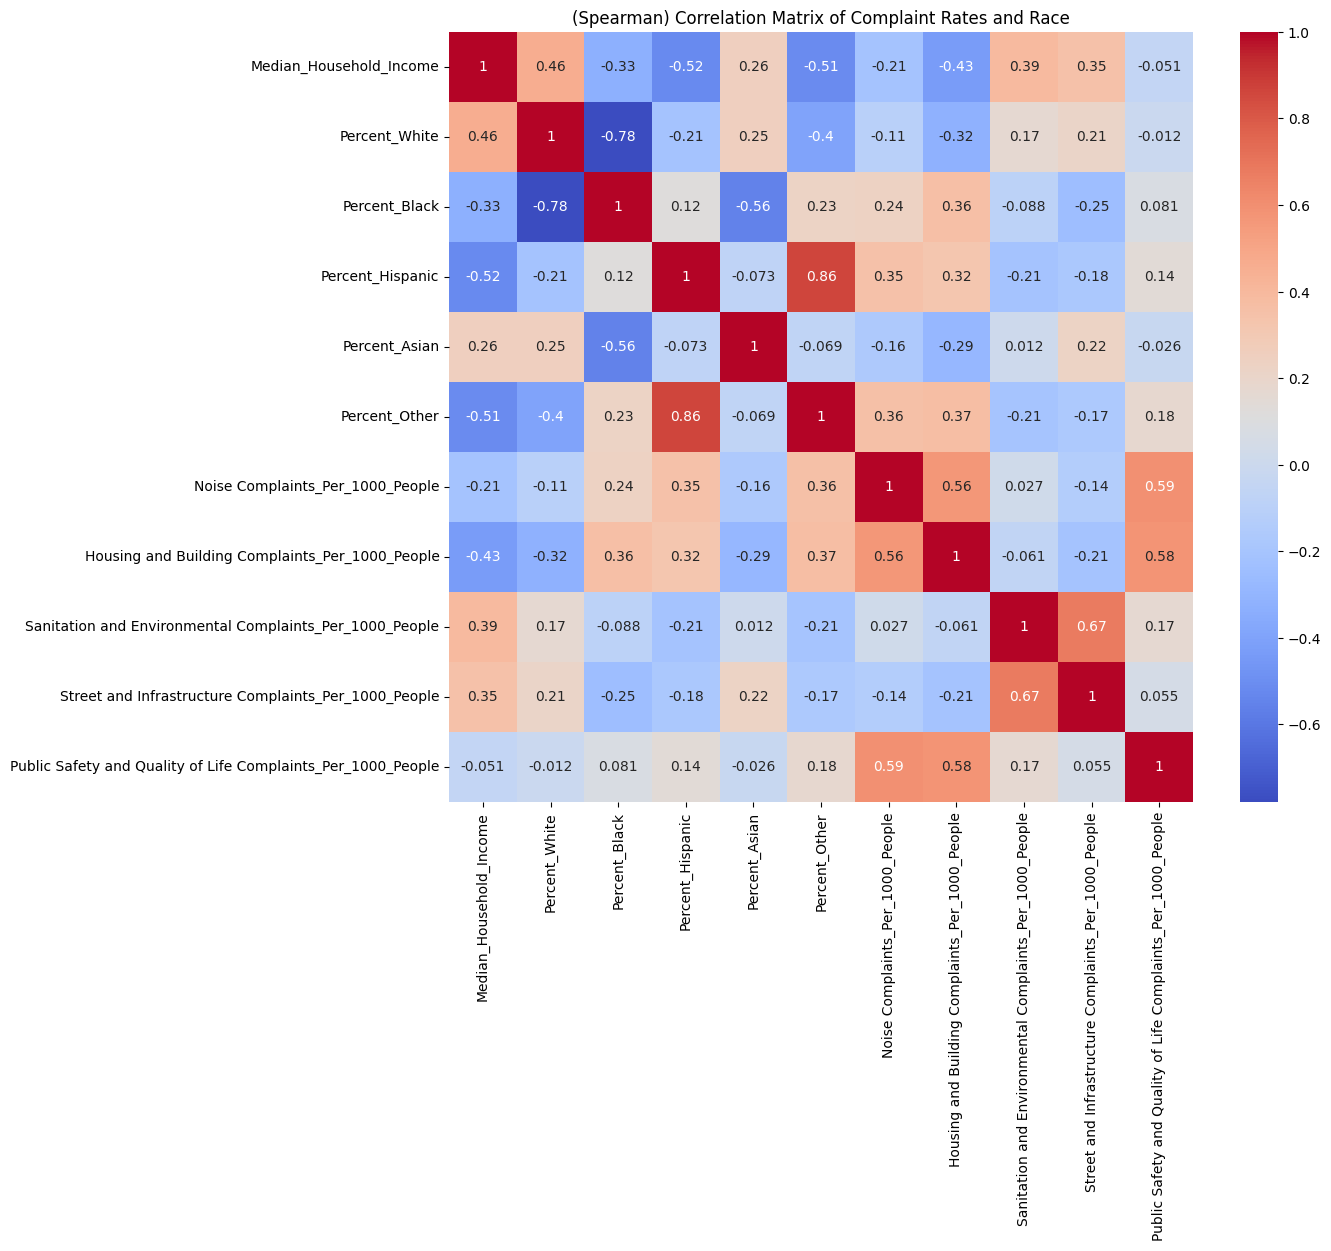

In [22]:
#Spearman
corr_matrix = analysis_data.corr(method = 'spearman')
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('(Spearman) Correlation Matrix of Complaint Rates and Race')
plt.show()

In [23]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

#Noise Complaints

#adjust for 0
analysis_data = analysis_data[analysis_data['Median_Household_Income'] > 0].copy()

#log transform median income
analysis_data['Log_Income'] = np.log(analysis_data['Median_Household_Income'])

#log-transform dependent var with +1 to handle potential zeros
analysis_data['Log_Noise_Complaints'] = np.log(analysis_data['Noise Complaints_Per_1000_People'] + 1)

#dependent
Y = analysis_data['Log_Noise_Complaints']

#independents
X = analysis_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]


valid_data = pd.concat([X, Y], axis=1).dropna()
X = valid_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]
Y = valid_data['Log_Noise_Complaints']


#maintain consistency
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, index=X.index, columns=X.columns)

X_scaled = sm.add_constant(X_scaled)
Y_aligned = Y.loc[X_scaled.index]


model = sm.OLS(Y_aligned, X_scaled).fit()

#regular OLS
print("Regular OLS Results with log-transformed dependent variable:")
print(model.summary())

#adjust for standard errors/heteroskedasticity with HC1
robust_hc1 = model.get_robustcov_results(cov_type='HC1')
print("\nOLS Results with HC1 robust standard errors (log-transformed Y):")
print(robust_hc1.summary())

#HC3
robust_hc3 = model.get_robustcov_results(cov_type='HC3')
print("\nOLS Results with HC3 robust standard errors (log-transformed Y):")
print(robust_hc3.summary())

Regular OLS Results with log-transformed dependent variable:
                             OLS Regression Results                             
Dep. Variable:     Log_Noise_Complaints   R-squared:                       0.137
Model:                              OLS   Adj. R-squared:                  0.136
Method:                   Least Squares   F-statistic:                     83.13
Date:                  Tue, 03 Mar 2026   Prob (F-statistic):           1.44e-65
Time:                          01:16:26   Log-Likelihood:                -2411.2
No. Observations:                  2093   AIC:                             4832.
Df Residuals:                      2088   BIC:                             4861.
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

In [24]:
#Housing and Building Complaints

#log-transform dependent var with +1 to handle potential zeros
analysis_data['Log_HNB_Complaints'] = np.log(analysis_data['Housing and Building Complaints_Per_1000_People'] + 1)

#dependent
Y = analysis_data['Log_HNB_Complaints']

#independents
X = analysis_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]


valid_data = pd.concat([X, Y], axis=1).dropna()
X = valid_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]
Y = valid_data['Log_HNB_Complaints']


#maintain consistency
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, index=X.index, columns=X.columns)

X_scaled = sm.add_constant(X_scaled)
Y_aligned = Y.loc[X_scaled.index]


model = sm.OLS(Y_aligned, X_scaled).fit()

#regular OLS
print("Regular OLS Results with log-transformed dependent variable:")
print(model.summary())

#adjust for standard errors/heteroskedasticity with HC1
robust_hc1 = model.get_robustcov_results(cov_type='HC1')
print("\nOLS Results with HC1 robust standard errors (log-transformed Y):")
print(robust_hc1.summary())

#HC3
robust_hc3 = model.get_robustcov_results(cov_type='HC3')
print("\nOLS Results with HC3 robust standard errors (log-transformed Y):")
print(robust_hc3.summary())

Regular OLS Results with log-transformed dependent variable:
                            OLS Regression Results                            
Dep. Variable:     Log_HNB_Complaints   R-squared:                       0.196
Model:                            OLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     127.5
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.73e-97
Time:                        01:16:26   Log-Likelihood:                -2551.8
No. Observations:                2093   AIC:                             5114.
Df Residuals:                    2088   BIC:                             5142.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

In [25]:
#Sanitation and Environmental Complaints

#log-transform dependent var with +1 to handle potential zeros
analysis_data['Log_SNE_Complaints'] = np.log(analysis_data['Sanitation and Environmental Complaints_Per_1000_People'] + 1)

#dependent
Y = analysis_data['Log_SNE_Complaints']

#independents
X = analysis_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]


valid_data = pd.concat([X, Y], axis=1).dropna()
X = valid_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]
Y = valid_data['Log_SNE_Complaints']


#maintain consistency
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, index=X.index, columns=X.columns)

X_scaled = sm.add_constant(X_scaled)
Y_aligned = Y.loc[X_scaled.index]


model = sm.OLS(Y_aligned, X_scaled).fit()

#regular OLS
print("Regular OLS Results with log-transformed dependent variable:")
print(model.summary())

#adjust for standard errors/heteroskedasticity with HC1
robust_hc1 = model.get_robustcov_results(cov_type='HC1')
print("\nOLS Results with HC1 robust standard errors (log-transformed Y):")
print(robust_hc1.summary())

#HC3
robust_hc3 = model.get_robustcov_results(cov_type='HC3')
print("\nOLS Results with HC3 robust standard errors (log-transformed Y):")
print(robust_hc3.summary())

Regular OLS Results with log-transformed dependent variable:
                            OLS Regression Results                            
Dep. Variable:     Log_SNE_Complaints   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     94.32
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           7.89e-74
Time:                        01:16:26   Log-Likelihood:                -1626.9
No. Observations:                2093   AIC:                             3264.
Df Residuals:                    2088   BIC:                             3292.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

In [26]:
#Street and Infrastructure Complaints

#log-transform dependent var with +1 to handle potential zeros
analysis_data['Log_SNI_Complaints'] = np.log(analysis_data['Street and Infrastructure Complaints_Per_1000_People'] + 1)

#dependent
Y = analysis_data['Log_SNI_Complaints']

#independents
X = analysis_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]


valid_data = pd.concat([X, Y], axis=1).dropna()
X = valid_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]
Y = valid_data['Log_SNI_Complaints']


#maintain consistency
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, index=X.index, columns=X.columns)

X_scaled = sm.add_constant(X_scaled)
Y_aligned = Y.loc[X_scaled.index]


model = sm.OLS(Y_aligned, X_scaled).fit()

#regular OLS
print("Regular OLS Results with log-transformed dependent variable:")
print(model.summary())

#adjust for standard errors/heteroskedasticity with HC1
robust_hc1 = model.get_robustcov_results(cov_type='HC1')
print("\nOLS Results with HC1 robust standard errors (log-transformed Y):")
print(robust_hc1.summary())

#HC3
robust_hc3 = model.get_robustcov_results(cov_type='HC3')
print("\nOLS Results with HC3 robust standard errors (log-transformed Y):")
print(robust_hc3.summary())

Regular OLS Results with log-transformed dependent variable:
                            OLS Regression Results                            
Dep. Variable:     Log_SNI_Complaints   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     94.64
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           4.59e-74
Time:                        01:16:26   Log-Likelihood:                -1937.6
No. Observations:                2093   AIC:                             3885.
Df Residuals:                    2088   BIC:                             3913.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

In [27]:
#Public Safety and Quality of Life Complaints

#log-transform dependent var with +1 to handle potential zeros
analysis_data['Log_PSQL_Complaints'] = np.log(analysis_data['Public Safety and Quality of Life Complaints_Per_1000_People'] + 1)

#dependent
Y = analysis_data['Log_PSQL_Complaints']

#independents
X = analysis_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]


valid_data = pd.concat([X, Y], axis=1).dropna()
X = valid_data[['Log_Income', 'Percent_Asian', 'Percent_Black', 'Percent_Hispanic']]
Y = valid_data['Log_PSQL_Complaints']


#maintain consistency
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, index=X.index, columns=X.columns)

X_scaled = sm.add_constant(X_scaled)
Y_aligned = Y.loc[X_scaled.index]


model = sm.OLS(Y_aligned, X_scaled).fit()

#regular OLS
print("Regular OLS Results with log-transformed dependent variable:")
print(model.summary())

#adjust for standard errors/heteroskedasticity with HC1
robust_hc1 = model.get_robustcov_results(cov_type='HC1')
print("\nOLS Results with HC1 robust standard errors (log-transformed Y):")
print(robust_hc1.summary())

#HC3
robust_hc3 = model.get_robustcov_results(cov_type='HC3')
print("\nOLS Results with HC3 robust standard errors (log-transformed Y):")
print(robust_hc3.summary())

Regular OLS Results with log-transformed dependent variable:
                             OLS Regression Results                            
Dep. Variable:     Log_PSQL_Complaints   R-squared:                       0.031
Model:                             OLS   Adj. R-squared:                  0.029
Method:                  Least Squares   F-statistic:                     16.50
Date:                 Tue, 03 Mar 2026   Prob (F-statistic):           2.55e-13
Time:                         01:16:26   Log-Likelihood:                -2518.7
No. Observations:                 2093   AIC:                             5047.
Df Residuals:                     2088   BIC:                             5076.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

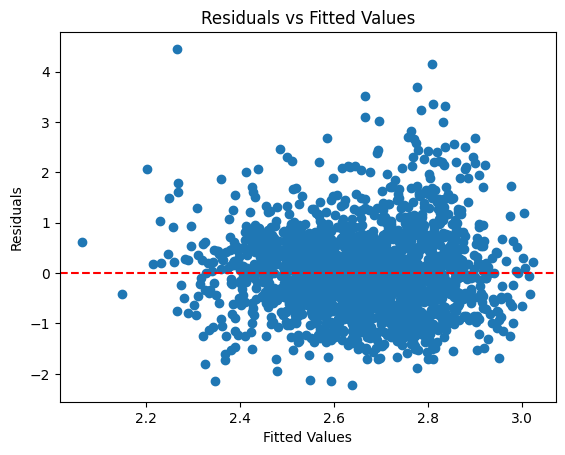

In [28]:
residuals = model.resid
fitted_values = model.fittedvalues

plt.scatter(fitted_values, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

In [38]:
from esda.moran import Moran
from esda.moran import Moran_Local
from libpysal.weights import Queen

/var/folders/dn/l049vy7s08vdd1gsbz4bq_d00000gn/T/ipykernel_32525/1414549075.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(acs_tiger)
/Users/marquiswong/Desktop/projects/nyc311urbandata/.venv/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There are 2 islands with ids: 550, 1593.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 550, ' is an island (no neighbors)')
('WARNING: ', 1593, ' is an island (no neighbors)')


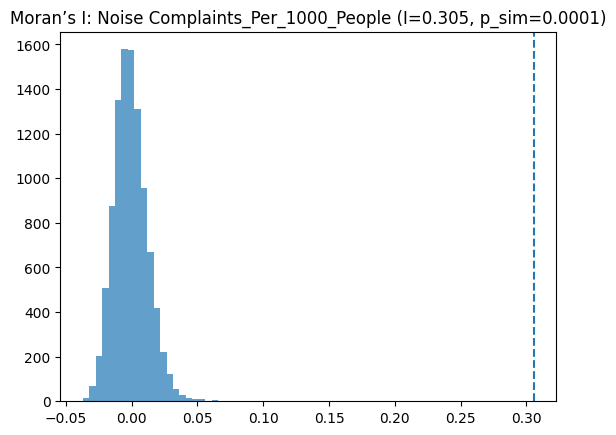

In [39]:
def moran_with_perms(gdf, col, w, permutations=9999):
    x = gdf[col].astype(float).replace([np.inf, -np.inf], np.nan).fillna(0)
    return Moran(x, w, permutations=permutations)


w = Queen.from_dataframe(acs_tiger)
w.transform = "r"


rate_cols = [f"{c}_Per_1000_People" for c in complaint_categories_list]
morans = {col: moran_with_perms(acs_tiger, col, w) for col in rate_cols}


col = rate_cols[0]
m = morans[col]
plt.hist(m.sim, bins=30, alpha=0.7)
plt.axvline(m.I, linestyle="--")
plt.title(f"Moran’s I: {col} (I={m.I:.3f}, p_sim={m.p_sim:.4f})")
plt.show()

In [36]:
#latitude and longitude range 
#plt.xlim([-74.3, -73.7]) #long
#plt.ylim([40.4, 41])     #lat

In [40]:
rate_cols = [f"{c}_Per_1000_People" for c in complaint_categories_list]

df = acs_tiger[['Median_Household_Income'] + rate_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
df = df[df['Median_Household_Income'] > 0].copy()

# income quintiles
df['income_quintile'] = pd.qcut(df['Median_Household_Income'], 5, labels=['Q1_low','Q2','Q3','Q4','Q5_high'])

quint = df.groupby('income_quintile')[rate_cols].mean().T
quint['Q1_over_Q5'] = quint['Q1_low'] / quint['Q5_high']
quint['Q1_minus_Q5'] = quint['Q1_low'] - quint['Q5_high']

# correlations
corr_rows = []
for col in rate_cols:
    pear = df['Median_Household_Income'].corr(df[col], method='pearson')
    spear = df['Median_Household_Income'].corr(df[col], method='spearman')
    corr_rows.append([col, pear, spear])

corr_tbl = pd.DataFrame(corr_rows, columns=['metric','pearson_r','spearman_rho']).set_index('metric')

summary = quint.join(corr_tbl, how='left')
summary = summary.sort_values('Q1_over_Q5', ascending=False)
summary

,Q1_low,Q2,Q3,Q4,Q5_high,Q1_over_Q5,Q1_minus_Q5,pearson_r,spearman_rho
Housing and Building Complaints_Per_1000_People,120.307668,103.468253,63.000379,47.275288,39.724821,3.028526,80.582847,-0.374437,-0.443606
Noise Complaints_Per_1000_People,61.975067,49.020518,43.283415,37.513036,46.830727,1.323385,15.144340,-0.036486,-0.220815
Sanitation and Environmental Complaints_Per_1000_People,31.012913,39.734120,43.713210,51.471254,55.191525,0.561914,-24.178612,0.292365,0.393699
Street and Infrastructure Complaints_Per_1000_People,51.152208,78.908134,97.882191,94.890177,93.372868,0.547827,-42.220661,0.191419,0.349312
Public Safety and Quality of Life Complaints_Per_1000_People,18.880556,17.662252,15.541234,15.017963,41.101149,0.459368,-22.220593,0.237641,-0.055114


In [41]:
from sklearn.cluster import KMeans

mix = acs_tiger[rate_cols].replace([np.inf, -np.inf], np.nan).fillna(0).copy()

scaler = StandardScaler()
X = scaler.fit_transform(mix)

k = 5  # try 4–6
km = KMeans(n_clusters=k, random_state=42, n_init='auto')
acs_tiger['segment'] = km.fit_predict(X)

# segment profiles (mean rates)
seg_profile = acs_tiger.groupby('segment')[rate_cols].mean()
seg_profile

,Noise Complaints_Per_1000_People,Housing and Building Complaints_Per_1000_People,Sanitation and Environmental Complaints_Per_1000_People,Street and Infrastructure Complaints_Per_1000_People,Public Safety and Quality of Life Complaints_Per_1000_People
segment,,,,,
0,80.338924,182.136274,36.811776,50.849302,25.670481
1,33.461759,48.123757,29.739623,61.046716,14.474606
2,32.381645,43.393769,64.919569,122.976553,15.906403
3,210.359915,106.033938,159.434702,229.757557,624.099690
4,206.746094,92.702412,104.688215,250.937125,106.777859


In [42]:
def top_cats(row, cols, topn=2):
    s = row[cols].sort_values(ascending=False)
    return " + ".join([c.replace('_Per_1000_People','') for c in s.index[:topn]])

seg_profile['persona'] = seg_profile.apply(lambda r: top_cats(r, rate_cols, 2), axis=1)
seg_profile[['persona']]

,persona
segment,
0,Housing and Building Complaints + Noise Compla...
1,Street and Infrastructure Complaints + Housing...
2,Street and Infrastructure Complaints + Sanitat...
3,Public Safety and Quality of Life Complaints +...
4,Street and Infrastructure Complaints + Noise C...


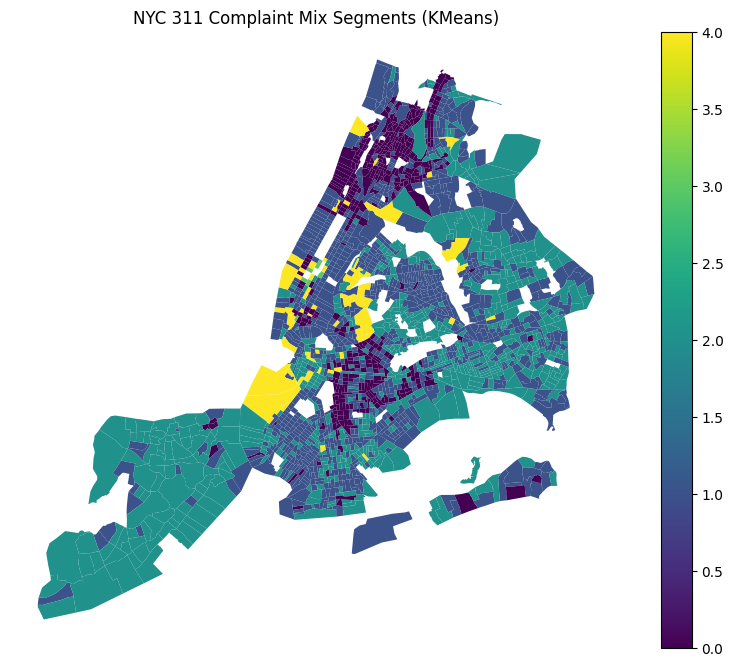

In [43]:
import matplotlib.pyplot as plt
acs_tiger.plot(column='segment', legend=True, figsize=(10,8))
plt.title("NYC 311 Complaint Mix Segments (KMeans)")
plt.axis('off')
plt.show()

In [44]:
target_metric = "Noise Complaints_Per_1000_People"  # change to any rate col
K_values = [25, 50, 100, 150, 200]
effect = 0.20  # assumed reduction in targeted tracts

df = acs_tiger[['Median_Household_Income', target_metric]].replace([np.inf, -np.inf], np.nan).dropna().copy()
df = df[df['Median_Household_Income'] > 0].copy()
df['income_quintile'] = pd.qcut(df['Median_Household_Income'], 5, labels=['Q1_low','Q2','Q3','Q4','Q5_high'])

def simulate(policy, K):
    d = df.copy()

    if policy == "efficient":
        # target highest complaint rates
        idx = d[target_metric].nlargest(K).index
    elif policy == "equity":
        # target within lowest-income quintile first, by highest rates
        low = d[d['income_quintile'] == 'Q1_low']
        idx = low[target_metric].nlargest(min(K, len(low))).index
    else:
        raise ValueError("unknown policy")

    d['reduction'] = 0.0
    d.loc[idx, 'reduction'] = effect * d.loc[idx, target_metric]

    total_reduction = d['reduction'].sum()
    by_quint = d.groupby('income_quintile')['reduction'].sum()
    equity_share_Q1 = by_quint.get('Q1_low', 0.0) / (total_reduction + 1e-12)

    return total_reduction, equity_share_Q1, by_quint

rows = []
for K in K_values:
    eff_red, eff_q1share, _ = simulate("efficient", K)
    eq_red,  eq_q1share,  _ = simulate("equity", K)
    rows.append([K, eff_red, eff_q1share, eq_red, eq_q1share])

tradeoff = pd.DataFrame(rows, columns=['K_trcts','efficient_total_reduction','efficient_Q1_share','equity_total_reduction','equity_Q1_share'])
tradeoff

,K_trcts,efficient_total_reduction,efficient_Q1_share,equity_total_reduction,equity_Q1_share
0,25,1846.810544,0.358638,1157.853768,1.0
1,50,2794.432535,0.288917,1715.663102,1.0
2,100,4215.603568,0.244573,2618.505455,1.0
3,150,5405.170544,0.266328,3284.437091,1.0
4,200,6462.569109,0.274853,3835.858127,1.0


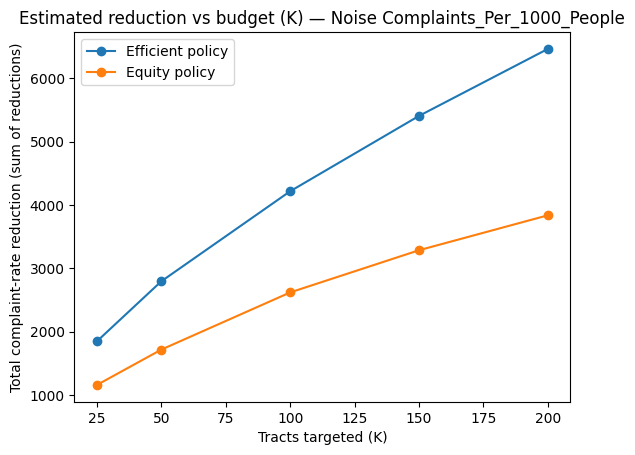

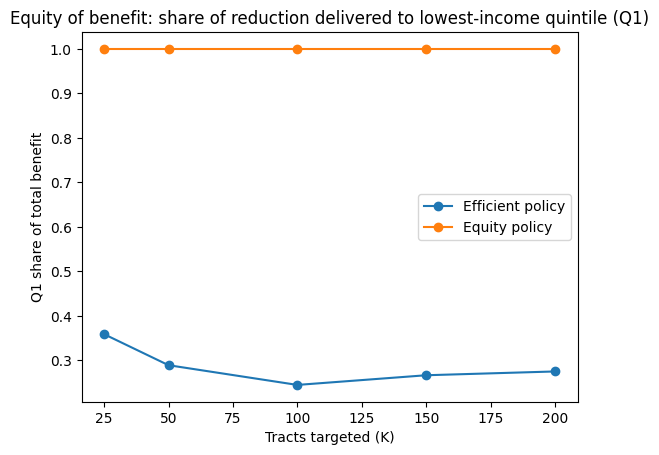

In [45]:
plt.plot(tradeoff['K_trcts'], tradeoff['efficient_total_reduction'], marker='o', label='Efficient policy')
plt.plot(tradeoff['K_trcts'], tradeoff['equity_total_reduction'], marker='o', label='Equity policy')
plt.title(f"Estimated reduction vs budget (K) — {target_metric}")
plt.xlabel("Tracts targeted (K)")
plt.ylabel("Total complaint-rate reduction (sum of reductions)")
plt.legend()
plt.show()

plt.plot(tradeoff['K_trcts'], tradeoff['efficient_Q1_share'], marker='o', label='Efficient policy')
plt.plot(tradeoff['K_trcts'], tradeoff['equity_Q1_share'], marker='o', label='Equity policy')
plt.title("Equity of benefit: share of reduction delivered to lowest-income quintile (Q1)")
plt.xlabel("Tracts targeted (K)")
plt.ylabel("Q1 share of total benefit")
plt.legend()
plt.show()

In [47]:
# pick a category where "need" is most plausible: Housing/Building
y = "Housing and Building Complaints_Per_1000_People"

d = acs_tiger[['GEOID','COUNTY','Median_Household_Income','segment', y]].replace([np.inf, -np.inf], np.nan).dropna().copy()
d = d[d['Median_Household_Income'] > 0].copy()

# log transforms to reduce heavy tails
d['log_income'] = np.log(d['Median_Household_Income'])
d['log_y'] = np.log(d[y] + 1)

# expected reporting within peer group (borough + segment) using group mean
grp = ['COUNTY','segment']
d['peer_expected'] = d.groupby(grp)['log_y'].transform('mean')

# residual vs peers (negative = under-reporting relative to peers)
d['peer_residual'] = d['log_y'] - d['peer_expected']

# underserved index: high issue burden but under-reporting vs peers
# (need proxy here is the actual housing/building rate; you can also use percentile)
d['need_proxy'] = (d['log_y'] - d['log_y'].mean()) / d['log_y'].std(ddof=0)
d['underserved_score'] = d['need_proxy'] * (-d['peer_residual'])

d.sort_values('underserved_score', ascending=False).head(20)[
    ['GEOID','COUNTY','segment', y,'Median_Household_Income','peer_residual','underserved_score']

,GEOID,COUNTY,segment,Housing and Building Complaints_Per_1000_People,Median_Household_Income,peer_residual,underserved_score
1874,36085002900,Richmond County,0,117.624594,27063.0,-0.558557,0.505482
1095,36005015900,Bronx County,0,92.500000,15033.0,-0.718815,0.463233
363,36005012300,Bronx County,0,109.940920,24474.0,-0.547779,0.455572
507,36005028500,Bronx County,0,112.971985,59556.0,-0.520824,0.448522
1255,36005033000,Bronx County,0,115.304348,37648.0,-0.500566,0.442177
332,36005008700,Bronx County,0,115.732087,29152.0,-0.496895,0.440931
1266,36005006000,Bronx County,0,116.627266,39783.0,-0.489256,0.438244
2008,36005037504,Bronx County,0,118.087558,19683.0,-0.476918,0.433633
278,36005022300,Bronx County,0,118.408345,23947.0,-0.474228,0.432584
378,36005042300,Bronx County,0,118.841241,33194.0,-0.470609,0.431147


In [55]:
# build weights if you haven't already
w = Queen.from_dataframe(acs_tiger)
w.transform = "r"

target = "Noise Complaints_Per_1000_People"
vals = acs_tiger[target].to_numpy(dtype=float)
y = np.log(vals + 1)

nbr_mean = np.full(len(y), np.nan)
nbr_std  = np.full(len(y), np.nan)
nbr_n    = np.zeros(len(y), dtype=int)

for i in range(len(y)):
    nbrs = w.neighbors.get(i, [])
    nbr_n[i] = len(nbrs)
    if len(nbrs) >= 3:  # require at least 3 neighbors
        yy = y[nbrs]
        nbr_mean[i] = np.nanmean(yy)
        nbr_std[i] = np.nanstd(yy)

# guardrail: floor std to prevent exploding z-scores
std_floor = np.nanpercentile(nbr_std, 10)  # or set a small constant like 0.05
nbr_std_safe = np.where(np.isnan(nbr_std), np.nan, np.maximum(nbr_std, std_floor))

acs_tiger['nbr_n'] = nbr_n
acs_tiger['local_z_safe'] = (y - nbr_mean) / (nbr_std_safe + 1e-6)

acs_tiger[['GEOID','COUNTY',target,'nbr_n','local_z_safe']].sort_values('local_z_safe', ascending=False).head(20)

/var/folders/dn/l049vy7s08vdd1gsbz4bq_d00000gn/T/ipykernel_32525/2002258101.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(acs_tiger)


('WARNING: ', 550, ' is an island (no neighbors)')
('WARNING: ', 1593, ' is an island (no neighbors)')


/Users/marquiswong/Desktop/projects/nyc311urbandata/.venv/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There are 2 islands with ids: 550, 1593.
  W.__init__(self, neighbors, ids=ids, **kw)


,GEOID,COUNTY,Noise Complaints_Per_1000_People,nbr_n,local_z_safe
255,36005007000,Bronx County,514.829208,4,11.257474
1252,36047003700,Kings County,496.705107,8,8.201503
75,36047065200,Kings County,231.111111,8,7.966921
1249,36047002901,Kings County,1016.200295,4,6.903540
47,36081094700,Queens County,143.807763,6,6.788608
329,36047011900,Kings County,696.493349,12,6.691912
1537,36081037300,Queens County,130.304168,5,6.239908
214,36047048600,Kings County,91.818182,6,5.545719
115,36047024900,Kings County,299.667300,7,5.489709
543,36005040701,Bronx County,262.738854,6,5.399474


In [60]:
islands = w.islands
print(islands)
acs_tiger.loc[islands, ['GEOID','COUNTY']].head()

[550, 1593]


,GEOID,COUNTY
550,36081015900,Queens County
1593,36081014700,Queens County


In [61]:
acs_tiger_no_islands = acs_tiger.drop(index=islands).copy()

In [62]:
from libpysal.weights import KNN
w_knn = KNN.from_dataframe(acs_tiger, k=8)
w_knn.transform = "r"

/Users/marquiswong/Desktop/projects/nyc311urbandata/.venv/lib/python3.13/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


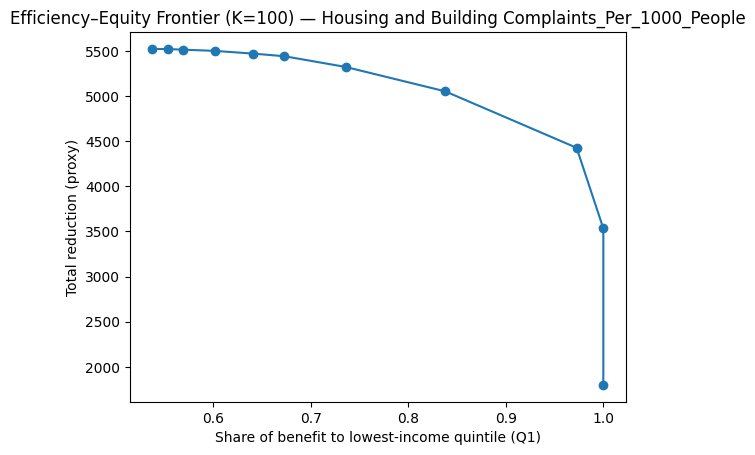

,alpha_efficiency,total_reduction_proxy,Q1_share
0,0.0,1800.335553,1.000000
1,0.1,3533.358805,1.000000
2,0.2,4426.685207,0.972647
3,0.3,5052.301941,0.837968
4,0.4,5322.548255,0.735902
5,0.5,5441.297489,0.673134
6,0.6,5470.676688,0.640716
7,0.7,5500.579662,0.601551
8,0.8,5513.913139,0.569636
9,0.9,5520.807031,0.553663


In [65]:
def efficiency_equity_frontier(gdf, target_metric, K=100, effect=0.20):
    d = gdf[['Median_Household_Income', target_metric]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    d = d[d['Median_Household_Income'] > 0].copy()
    d['income_quintile'] = pd.qcut(d['Median_Household_Income'], 5, labels=['Q1_low','Q2','Q3','Q4','Q5_high'])

    # z-scores
    d['z_complaint'] = (d[target_metric] - d[target_metric].mean()) / d[target_metric].std(ddof=0)
    d['z_low_income'] = -((d['Median_Household_Income'] - d['Median_Household_Income'].mean()) / d['Median_Household_Income'].std(ddof=0))

    alphas = np.linspace(0, 1, 11)
    rows = []

    for a in alphas:
        score = a * d['z_complaint'] + (1-a) * d['z_low_income']
        idx = score.nlargest(K).index

        reduction = pd.Series(0.0, index=d.index)
        reduction.loc[idx] = effect * d.loc[idx, target_metric]  # proxy impact

        total_red = reduction.sum()
        q1_share = reduction[d['income_quintile']=='Q1_low'].sum() / (total_red + 1e-12)

        rows.append([a, total_red, q1_share])

    frontier = pd.DataFrame(rows, columns=['alpha_efficiency','total_reduction_proxy','Q1_share'])

    # plot
    plt.plot(frontier['Q1_share'], frontier['total_reduction_proxy'], marker='o')
    plt.xlabel("Share of benefit to lowest-income quintile (Q1)")
    plt.ylabel("Total reduction (proxy)")
    plt.title(f"Efficiency–Equity Frontier (K={K}) — {target_metric}")
    plt.show()

    return frontier

frontier_housing = efficiency_equity_frontier(
    acs_tiger,
    target_metric="Housing and Building Complaints_Per_1000_People",
    K=100,
    effect=0.20
)

frontier_housing